# Depot vs. Private Insurance

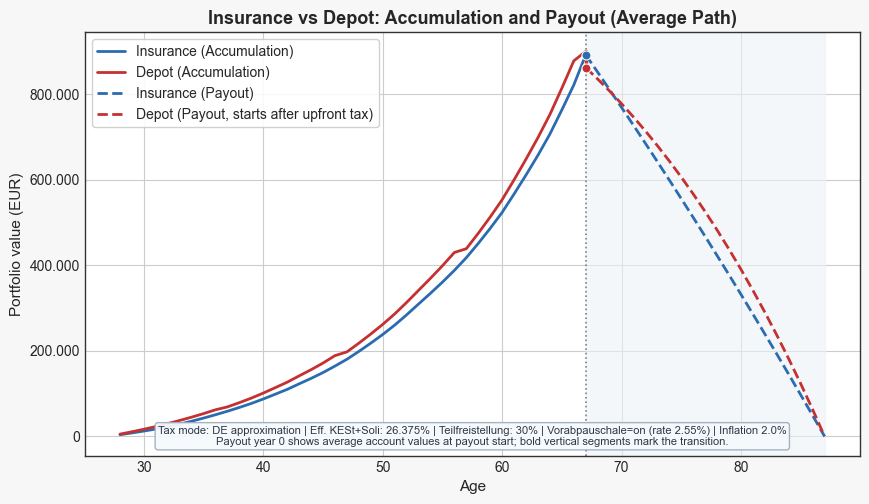

Tax setting: Tax mode: DE approximation | Eff. KESt+Soli: 26.375% | Teilfreistellung: 30%
Insurance payout tax mode: annuity_18pct_x_25pct
Insurance effective payout tax in this run: 4.50%

Result type A: amount gathered before payout starts
Insurance pot before payout starts (EUR): 888,044.53
Depot pot before payout starts after all modeled depot taxes due at payout start (EUR): 900,926.73

Result type B: final overall money outcome after full payout horizon
Insurance final overall money outcome (nominal, EUR): 891,207.99
Depot final overall money outcome (nominal, EUR):     1,116,397.65
Insurance final overall money outcome (real, EUR):    726,384.42
Depot final overall money outcome (real, EUR):        900,926.73
Total Vorabpauschale tax paid:                        44,877.84 EUR
Total Rebalancing tax paid:                           117,559.68 EUR


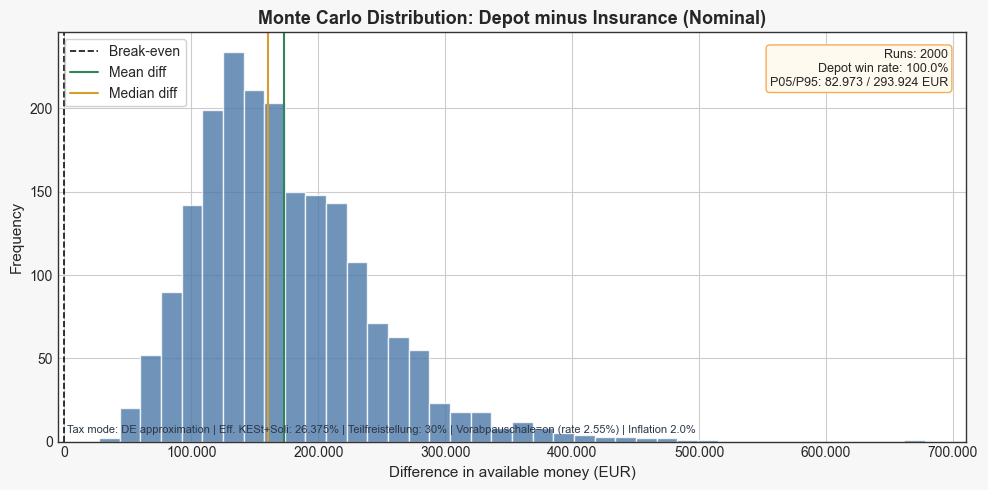

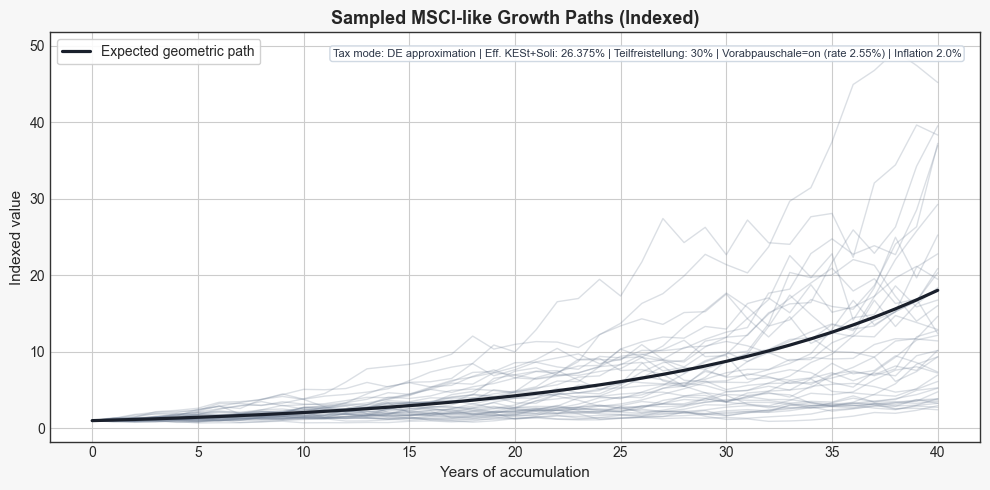


Monte Carlo interpretation
Depot - Insurance in Monte Carlo means the final overall money outcome after the full payout horizon (not just payout start).
Monte Carlo runs: 2000
Depot win rate (nominal): 100.0%
Monte Carlo average final outcomes (result type B):
  Insurance nominal avg: 894,633.68 EUR
  Depot nominal avg:     1,067,622.67 EUR
  Insurance real avg:    729,176.54 EUR
  Depot real avg:        861,565.60 EUR


In [77]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import random
import statistics


# --- Plot style helpers ---
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "#f7f7f7",
        "axes.facecolor": "#ffffff",
        "axes.edgecolor": "#333333",
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "font.size": 10,
    }
)


# --- Utility helpers ---
def percentile(values, p):
    if not values:
        return 0.0
    s = sorted(values)
    k = (len(s) - 1) * p
    f = int(k)
    c = min(f + 1, len(s) - 1)
    if f == c:
        return s[f]
    return s[f] * (c - k) + s[c] * (k - f)


def discounted_sum(cashflows, inflation_rate):
    return sum(cf / ((1 + inflation_rate) ** year) for year, cf in enumerate(cashflows, start=1))


def effective_abgeltungsteuer_rate(base_rate, soli_rate):
    return base_rate * (1 + soli_rate)


def insurance_payout_tax_rate(config):
    mode = config.get("insurance_tax_mode", "flat_rate")
    if mode == "annuity_18pct_x_25pct":
        return (
            config["insurance_annuity_taxable_share"]
            * config["insurance_retirement_income_tax_rate"]
        )
    return config["insurance_payout_tax"]


def format_number_de(value, decimals=0):
    us = f"{value:,.{decimals}f}"
    return us.replace(",", "X").replace(".", ",").replace("X", ".")


def german_int_tick(value, _):
    return format_number_de(value, 0)


def tax_label(config):
    effective_rate = config["effective_tax_rate"] * 100
    return (
        f"Tax mode: {config['tax_mode_label']} | "
        f"Eff. KESt+Soli: {effective_rate:.3f}% | "
        f"Teilfreistellung: {config['teilfreistellung'] * 100:.0f}%"
    )


def reduce_lots_pro_rata(lots, cash_amount):
    if cash_amount <= 0:
        return lots
    total_value = sum(lot["value"] for lot in lots)
    if total_value <= 0:
        return lots

    for lot in lots:
        ratio = lot["value"] / total_value
        reduction = cash_amount * ratio
        lot["value"] = max(0.0, lot["value"] - reduction)
        lot["basis"] = min(lot["basis"], lot["value"])
    return lots


def increase_basis_pro_rata(lots, basis_increase):
    if basis_increase <= 0:
        return lots
    total_value = sum(lot["value"] for lot in lots)
    if total_value <= 0:
        return lots

    for lot in lots:
        ratio = lot["value"] / total_value
        lot["basis"] += basis_increase * ratio
        lot["basis"] = min(lot["basis"], lot["value"])
    return lots


# --- FIFO helper functions for the depot ---
def add_depot_lot(lots, amount):
    # Each new deposit becomes a separate lot.
    lots.append({"value": amount, "basis": amount})
    return lots


def apply_growth(lots, sampled_return):
    # Update the market value of each lot using the same sampled return
    for lot in lots:
        lot["value"] *= 1 + sampled_return
    return lots


def total_depot_value(lots):
    return sum(lot["value"] for lot in lots)


def total_cost_basis(lots):
    return sum(lot["basis"] for lot in lots)


def rebalance_depot_fifo(lots, rebalancing_ratio, effective_tax_rate, taxable_share):
    """
    Sells enough from the oldest lots (FIFO) so that a fraction 'rebalancing_ratio' of
    the total depot value is sold. Taxes are calculated on the gain of each sold part.
    The net proceeds are then reinvested as a new lot (with its basis set to the net proceeds).
    """
    total_value = total_depot_value(lots)
    target_sell = total_value * rebalancing_ratio
    sold = 0.0
    tax_total = 0.0

    # Sell from the oldest lots first
    while lots and sold < target_sell:
        lot = lots[0]
        if sold + lot["value"] <= target_sell:
            # Sell the entire lot.
            sold += lot["value"]
            gain = lot["value"] - lot["basis"]
            taxable_gain = gain * taxable_share if gain > 0 else 0.0
            tax_total += taxable_gain * effective_tax_rate
            lots.pop(0)
        else:
            # Sell a fraction of this lot.
            remaining_to_sell = target_sell - sold
            ratio = remaining_to_sell / lot["value"]
            sold += remaining_to_sell
            sold_basis = lot["basis"] * ratio
            gain = remaining_to_sell - sold_basis
            taxable_gain = gain * taxable_share if gain > 0 else 0.0
            tax_total += taxable_gain * effective_tax_rate
            # Adjust the current lot: subtract the sold portion from both value and basis.
            lot["value"] -= remaining_to_sell
            lot["basis"] -= sold_basis
            break
    # Reinvest the sold proceeds net of tax as a new lot.
    reinvested = target_sell - tax_total
    if reinvested > 0:
        lots.append({"value": reinvested, "basis": reinvested})

    return lots, tax_total


def apply_vorabpauschale(
    lots,
    annual_contribution,
    value_before_year,
    effective_tax_rate,
    vorab_basis_rate,
    teilfreistellung,
    annual_allowance_remaining,
):
    """
    Germany-closer approximation for accumulating ETFs:
    - Vorab-Bemessung capped by actual annual gain (excluding fresh contribution).
    - Teilfreistellung applied.
    - Annual Sparer-Pauschbetrag offset can reduce taxable amount.
    - Tax payment reduces depot value; taxed amount is added to basis.
    """
    value_after_growth = total_depot_value(lots)
    taxable_share = max(0.0, 1.0 - teilfreistellung)

    annual_gain_ex_contrib = max(0.0, value_after_growth - value_before_year - annual_contribution)
    vorab_base = max(0.0, value_before_year * vorab_basis_rate)
    vorab_taxable_pre_allowance = min(vorab_base, annual_gain_ex_contrib) * taxable_share

    allowance_used = min(annual_allowance_remaining, vorab_taxable_pre_allowance)
    taxable_after_allowance = max(0.0, vorab_taxable_pre_allowance - allowance_used)

    tax_due = taxable_after_allowance * effective_tax_rate
    tax_due = min(tax_due, total_depot_value(lots))

    reduce_lots_pro_rata(lots, tax_due)
    increase_basis_pro_rata(lots, taxable_after_allowance)

    annual_allowance_remaining -= allowance_used

    return {
        "lots": lots,
        "tax_due": tax_due,
        "taxable_amount_after_allowance": taxable_after_allowance,
        "allowance_remaining": annual_allowance_remaining,
    }


# --- Main simulation functions ---
def simulate_insurance_vs_depot(
    monthly_investment,  # EUR per month
    accumulation_years,  # years of saving
    annual_return,  # long-run expected return, e.g. 0.075
    volatility,  # annual std dev for return sampling
    rebalancing_interval,  # years between rebalancing events
    rebalancing_ratio,  # fraction sold/rebalanced at rebalance date
    effective_tax_rate,  # Abgeltungsteuer + Soli effective rate
    insurance_fixed_cost,  # EUR per year
    insurance_abschluss_cost,  # EUR per year in first years
    abschluss_years,  # number of years with abschluss cost
    insurance_asset_fee,  # annual percent on insurance assets
    include_vorabpauschale=True,
    vorab_basis_rate=0.0255,  # annual basis rate for Vorabpauschale approximation
    teilfreistellung=0.30,  # equity ETF partial exemption
    sparerpauschbetrag_annual=1000.0,  # annual allowance
):
    """
    Simulates accumulation for insurance vs. depot year-by-year.

    High-level flow per year:
    1) Add annual contribution and sample market return
    2) Apply insurance costs/fees and growth
    3) Apply depot growth, optional Vorabpauschale tax, optional rebalancing tax
    4) Store yearly values for plotting

    Returns final values plus tracking info (cost basis, taxes, sampled returns).
    """
    # Tracking arrays for plotting
    insurance_vals = []
    depot_vals = []
    sampled_returns = []

    # Insurance
    value_ins = 0.0
    total_paid_ins = 0.0

    # Depot (using FIFO lots)
    depot_lots = []
    total_paid_depot = 0.0
    total_vorab_tax_paid = 0.0
    total_rebalance_tax_paid = 0.0

    # Taxable share for equity ETF gains after Teilfreistellung (e.g. 70% at 30% exemption).
    taxable_share = max(0.0, 1.0 - teilfreistellung)

    # Accumulation phase
    for year in range(1, accumulation_years + 1):
        # Annual inputs: monthly contribution converted to yearly amount and one sampled market return.
        annual_allowance_remaining = max(0.0, sparerpauschbetrag_annual)
        annual_investment = monthly_investment * 12

        # Sample one annual return for this year (applied uniformly)
        sampled_return = random.normalvariate(annual_return, volatility)
        sampled_returns.append(sampled_return)

        # --- Insurance path ---
        # 1) Add contribution, 2) deduct fixed/abschluss costs, 3) deduct asset fee, 4) apply market return.
        # Costs for insurance
        total_paid_ins += annual_investment
        value_ins += annual_investment
        value_ins -= insurance_fixed_cost
        if year <= abschluss_years:
            value_ins -= insurance_abschluss_cost
        # Asset fee
        value_ins *= 1 - insurance_asset_fee
        # Growth for insurance with fluctuation
        value_ins *= 1 + sampled_return

        # --- Depot path ---
        # Keep previous year-end value for Vorabpauschale cap logic.
        value_before_year = total_depot_value(depot_lots)
        total_paid_depot += annual_investment
        add_depot_lot(depot_lots, annual_investment)
        # Same sampled market return is applied to all lots for this year.
        # Apply the same annual growth to all lots
        apply_growth(depot_lots, sampled_return)

        # Optional annual Vorabpauschale taxation (DE approximation).
        if include_vorabpauschale and sampled_return > 0 and value_before_year > 0:
            vorab = apply_vorabpauschale(
                lots=depot_lots,
                annual_contribution=annual_investment,
                value_before_year=value_before_year,
                effective_tax_rate=effective_tax_rate,
                vorab_basis_rate=vorab_basis_rate,
                teilfreistellung=teilfreistellung,
                annual_allowance_remaining=annual_allowance_remaining,
            )
            depot_lots = vorab["lots"]
            annual_allowance_remaining = vorab["allowance_remaining"]
            total_vorab_tax_paid += vorab["tax_due"]

        # Optional rebalancing (FIFO sell + immediate tax on taxable gains).
        if rebalancing_interval > 0 and year % rebalancing_interval == 0 and rebalancing_ratio > 0:
            depot_lots, rebalance_tax = rebalance_depot_fifo(
                depot_lots,
                rebalancing_ratio,
                effective_tax_rate=effective_tax_rate,
                taxable_share=taxable_share,
            )
            total_rebalance_tax_paid += rebalance_tax

        # Year-end snapshot used for charting and final comparison.
        # Compute overall depot value and cost basis for plotting and later taxation.
        value_depot = total_depot_value(depot_lots)
        cost_basis_depot = total_cost_basis(depot_lots)

        # Store for plotting
        insurance_vals.append(value_ins)
        depot_vals.append(value_depot)

    return {
        "insurance_vals": insurance_vals,
        "depot_vals": depot_vals,
        "final_ins": value_ins,
        "final_dep": value_depot,
        "cost_basis_depot": cost_basis_depot,
        "total_paid_ins": total_paid_ins,
        "total_paid_depot": total_paid_depot,
        "sampled_returns": sampled_returns,
        "total_vorab_tax_paid": total_vorab_tax_paid,
        "total_rebalance_tax_paid": total_rebalance_tax_paid,
    }


def simulate_payout_phase(
    insurance_start,
    depot_start,
    cost_basis_depot,
    payout_years=20,  # planned withdrawal horizon
    payout_return=0.02,  # shared low-risk return during payout phase
    insurance_payout_tax=0.10,  # simplified tax assumption for insurance payout
    insurance_payout_fee=0.015,  # annual cost during payout phase
    effective_tax_rate=0.26375,  # used for upfront depot taxation
    teilfreistellung=0.30,  # taxable share adjustment for depot gains
):
    """
    Payout phase assumptions in this notebook:
    - Depot: tax remaining untaxed gains once at payout start, then withdraw evenly.
    - Insurance: annual fee on remaining pot, then even withdrawal taxed at insurance_payout_tax.
    - Both products get the same low-risk return (payout_return) during payout.
    """
    insurance_vals = []
    depot_vals = []

    insurance_net_payouts = []
    depot_net_payouts = []

    # Depot tax at payout start: only the still-untaxed gain is taxed once.
    taxable_share = max(0.0, 1.0 - teilfreistellung)
    untaxed_gain = max(0.0, depot_start - cost_basis_depot)
    upfront_depot_tax = untaxed_gain * taxable_share * effective_tax_rate
    depot_start_after_tax = depot_start - upfront_depot_tax

    value_depot = depot_start_after_tax
    value_ins = insurance_start

    for year in range(1, payout_years + 1):
        # ============ INSURANCE Payout ============
        # Apply shared low-risk return, then insurance-specific fee and payout taxation.
        value_ins *= 1 + payout_return
        value_ins *= 1 - insurance_payout_fee
        payout_ins = value_ins / (payout_years - year + 1)
        tax_ins = payout_ins * insurance_payout_tax
        net_payout_ins = payout_ins - tax_ins
        value_ins -= payout_ins

        # ============ DEPOT Payout ============
        # Apply same low-risk return, then withdraw equal fractions (no additional payout tax here).
        value_depot *= 1 + payout_return
        payout_dep = value_depot / (payout_years - year + 1)
        value_depot -= payout_dep

        insurance_net_payouts.append(net_payout_ins)
        depot_net_payouts.append(payout_dep)
        insurance_vals.append(value_ins)
        depot_vals.append(value_depot)

    return {
        "ins_payout_vals": insurance_vals,
        "dep_payout_vals": depot_vals,
        "insurance_net_payouts": insurance_net_payouts,
        "depot_net_payouts": depot_net_payouts,
        "total_net_payout_ins": sum(insurance_net_payouts),
        "total_net_payout_dep": sum(depot_net_payouts),
        "final_ins_payout": value_ins,
        "final_dep_payout": value_depot,
        "upfront_depot_tax": upfront_depot_tax,
        "depot_start_after_tax": depot_start_after_tax,
    }


def run_single_simulation(config, seed=None):
    if seed is not None:
        random.seed(seed)

    payout_tax_rate_insurance = insurance_payout_tax_rate(config)

    sparerpauschbetrag_effective = (
        0.0 if config["assume_allowance_used_elsewhere"] else config["sparerpauschbetrag_annual"]
    )

    accum = simulate_insurance_vs_depot(
        monthly_investment=config["monthly_investment"],
        accumulation_years=config["accum_years"],
        annual_return=config["annual_return"],
        volatility=config["volatility"],
        rebalancing_interval=config["rebalancing_interval"],
        rebalancing_ratio=config["rebalancing_ratio"],
        effective_tax_rate=config["effective_tax_rate"],
        insurance_fixed_cost=config["insurance_fixed_cost"],
        insurance_abschluss_cost=config["insurance_abschluss_cost"],
        abschluss_years=config["abschluss_years"],
        insurance_asset_fee=config["insurance_asset_fee"],
        include_vorabpauschale=config["include_vorabpauschale"],
        vorab_basis_rate=config["vorab_basis_rate"],
        teilfreistellung=config["teilfreistellung"],
        sparerpauschbetrag_annual=sparerpauschbetrag_effective,
    )

    payout = simulate_payout_phase(
        insurance_start=accum["final_ins"],
        depot_start=accum["final_dep"],
        cost_basis_depot=accum["cost_basis_depot"],
        payout_years=config["payout_years"],
        payout_return=config["payout_return"],
        insurance_payout_tax=payout_tax_rate_insurance,
        insurance_payout_fee=config["insurance_payout_fee"],
        effective_tax_rate=config["effective_tax_rate"],
        teilfreistellung=config["teilfreistellung"],
    )

    nominal_available_ins = payout["total_net_payout_ins"] + payout["final_ins_payout"]
    nominal_available_dep = payout["total_net_payout_dep"] + payout["final_dep_payout"]

    real_available_ins = discounted_sum(
        payout["insurance_net_payouts"], config["inflation_rate"]
    ) + (payout["final_ins_payout"] / ((1 + config["inflation_rate"]) ** config["payout_years"]))
    real_available_dep = discounted_sum(payout["depot_net_payouts"], config["inflation_rate"]) + (
        payout["final_dep_payout"] / ((1 + config["inflation_rate"]) ** config["payout_years"])
    )

    return {
        "accum": accum,
        "payout": payout,
        "insurance_payout_tax_rate": payout_tax_rate_insurance,
        "nominal_available_ins": nominal_available_ins,
        "nominal_available_dep": nominal_available_dep,
        "real_available_ins": real_available_ins,
        "real_available_dep": real_available_dep,
    }


def run_monte_carlo(config, n_runs=2000, seed_start=10_000, sample_paths=40):
    if n_runs <= 0:
        raise ValueError("n_runs must be > 0")

    nominal_diffs = []
    real_diffs = []
    dep_wins = 0
    sampled_paths = []
    ins_nom_sum = 0.0
    dep_nom_sum = 0.0
    ins_real_sum = 0.0
    dep_real_sum = 0.0
    ins_accum_sum = [0.0] * config["accum_years"]
    dep_accum_sum = [0.0] * config["accum_years"]
    ins_payout_sum = [0.0] * config["payout_years"]
    dep_payout_sum = [0.0] * config["payout_years"]
    insurance_start_payout_sum = 0.0
    depot_start_payout_sum = 0.0

    for i in range(n_runs):
        run = run_single_simulation(config, seed=seed_start + i)

        dep_nom = run["nominal_available_dep"]
        ins_nom = run["nominal_available_ins"]
        dep_real = run["real_available_dep"]
        ins_real = run["real_available_ins"]

        nominal_diff = dep_nom - ins_nom
        real_diff = dep_real - ins_real

        nominal_diffs.append(nominal_diff)
        real_diffs.append(real_diff)
        ins_nom_sum += ins_nom
        dep_nom_sum += dep_nom
        ins_real_sum += ins_real
        dep_real_sum += dep_real

        ins_accum = run["accum"]["insurance_vals"]
        dep_accum = run["accum"]["depot_vals"]
        ins_payout = run["payout"]["ins_payout_vals"]
        dep_payout = run["payout"]["dep_payout_vals"]

        for j in range(len(ins_accum)):
            ins_accum_sum[j] += ins_accum[j]
            dep_accum_sum[j] += dep_accum[j]

        for j in range(len(ins_payout)):
            ins_payout_sum[j] += ins_payout[j]
            dep_payout_sum[j] += dep_payout[j]

        insurance_start_payout_sum += run["accum"]["final_ins"]
        depot_start_payout_sum += run["payout"]["depot_start_after_tax"]

        if nominal_diff > 0:
            dep_wins += 1

        if i < sample_paths:
            sampled_paths.append(run["accum"]["sampled_returns"])

    return {
        "n_runs": n_runs,
        "nominal_diffs": nominal_diffs,
        "real_diffs": real_diffs,
        "dep_win_rate": dep_wins / n_runs,
        "nominal_mean": statistics.mean(nominal_diffs),
        "nominal_median": statistics.median(nominal_diffs),
        "nominal_p05": percentile(nominal_diffs, 0.05),
        "nominal_p95": percentile(nominal_diffs, 0.95),
        "avg_nominal_ins": ins_nom_sum / n_runs,
        "avg_nominal_dep": dep_nom_sum / n_runs,
        "real_mean": statistics.mean(real_diffs),
        "real_median": statistics.median(real_diffs),
        "real_p05": percentile(real_diffs, 0.05),
        "real_p95": percentile(real_diffs, 0.95),
        "avg_real_ins": ins_real_sum / n_runs,
        "avg_real_dep": dep_real_sum / n_runs,
        "avg_ins_accum_path": [v / n_runs for v in ins_accum_sum],
        "avg_dep_accum_path": [v / n_runs for v in dep_accum_sum],
        "avg_ins_payout_path": [v / n_runs for v in ins_payout_sum],
        "avg_dep_payout_path": [v / n_runs for v in dep_payout_sum],
        "avg_insurance_start_payout": insurance_start_payout_sum / n_runs,
        "avg_depot_start_payout": depot_start_payout_sum / n_runs,
        "sampled_paths": sampled_paths,
    }


def assumptions_subtitle(config):
    return (
        f"{tax_label(config)} | Vorabpauschale={'on' if config['include_vorabpauschale'] else 'off'} "
        f"(rate {config['vorab_basis_rate'] * 100:.2f}%) | Inflation {config['inflation_rate'] * 100:.1f}%"
    )


def plot_results(
    curr_age,
    config,
    ins_accum,
    dep_accum,
    ins_payout,
    dep_payout,
    insurance_start_payout,
    depot_start_payout,
):
    accum_years = config["accum_years"]
    payout_years = config["payout_years"]

    fig, ax = plt.subplots(figsize=(10, 5.5))

    x_accum = range(curr_age + 1, curr_age + accum_years + 1)
    # Payout starts at year 0 with already adjusted start values (e.g. depot after upfront tax).
    x_payout = range(curr_age + accum_years, curr_age + accum_years + payout_years + 1)
    ins_payout_with_start = [insurance_start_payout] + ins_payout
    dep_payout_with_start = [depot_start_payout] + dep_payout

    ax.plot(x_accum, ins_accum, label="Insurance (Accumulation)", color="#2b6cb0", linewidth=2.0)
    ax.plot(x_accum, dep_accum, label="Depot (Accumulation)", color="#c53030", linewidth=2.0)

    ax.plot(
        x_payout,
        ins_payout_with_start,
        label="Insurance (Payout)",
        color="#2b6cb0",
        linestyle="--",
        linewidth=2.0,
    )
    ax.plot(
        x_payout,
        dep_payout_with_start,
        label="Depot (Payout, starts after upfront tax)",
        color="#c53030",
        linestyle="--",
        linewidth=2.0,
    )

    # Explicitly show the transition at payout start (age = curr_age + accum_years).
    boundary_age = curr_age + accum_years
    ax.axvline(boundary_age, color="#1a202c", linestyle=":", linewidth=1.2, alpha=0.55)
    ax.plot(
        [boundary_age, boundary_age],
        [ins_accum[-1], insurance_start_payout],
        color="#2b6cb0",
        linewidth=2.4,
        alpha=0.95,
        zorder=6,
    )
    ax.plot(
        [boundary_age, boundary_age],
        [dep_accum[-1], depot_start_payout],
        color="#c53030",
        linewidth=2.4,
        alpha=0.95,
        zorder=6,
    )
    ax.scatter(
        [boundary_age],
        [insurance_start_payout],
        color="#2b6cb0",
        edgecolor="white",
        linewidth=0.8,
        s=42,
        zorder=7,
    )
    ax.scatter(
        [boundary_age],
        [depot_start_payout],
        color="#c53030",
        edgecolor="white",
        linewidth=0.8,
        s=42,
        zorder=7,
    )

    ax.axvspan(
        curr_age + accum_years, curr_age + accum_years + payout_years, color="#edf2f7", alpha=0.6
    )

    ax.set_title("Insurance vs Depot: Accumulation and Payout (Average Path)")
    ax.set_xlabel("Age")
    ax.set_ylabel("Portfolio value (EUR)")
    ax.yaxis.set_major_formatter(FuncFormatter(german_int_tick))
    ax.legend(loc="upper left")
    ax.text(
        0.5,
        0.02,
        assumptions_subtitle(config)
        + "\nPayout year 0 shows average account values at payout start; bold vertical segments mark the transition.",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#2d3748",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "#f7fafc",
            "edgecolor": "#a0aec0",
            "alpha": 0.95,
        },
    )
    plt.show()


def plot_mc_difference_hist(mc, config):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(mc["nominal_diffs"], bins=40, alpha=0.8, color="#4c78a8", edgecolor="white")
    ax.axvline(0, color="#111111", linestyle="--", linewidth=1.2, label="Break-even")
    ax.axvline(mc["nominal_mean"], color="#2f855a", linestyle="-", linewidth=1.5, label="Mean diff")
    ax.axvline(
        mc["nominal_median"], color="#d69e2e", linestyle="-", linewidth=1.5, label="Median diff"
    )

    ax.set_title("Monte Carlo Distribution: Depot minus Insurance (Nominal)")
    ax.set_xlabel("Difference in available money (EUR)")
    ax.set_ylabel("Frequency")
    ax.xaxis.set_major_formatter(FuncFormatter(german_int_tick))
    ax.legend(loc="upper left")
    ax.text(
        0.98,
        0.96,
        (
            f"Runs: {mc['n_runs']}\n"
            f"Depot win rate: {mc['dep_win_rate'] * 100:.1f}%\n"
            f"P05/P95: {format_number_de(mc['nominal_p05'], 0)} / {format_number_de(mc['nominal_p95'], 0)} EUR"
        ),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "#fffaf0", "edgecolor": "#f6ad55"},
    )

    ax.text(
        0.01,
        0.02,
        assumptions_subtitle(config),
        transform=ax.transAxes,
        fontsize=8,
        color="#2d3748",
    )

    plt.tight_layout()
    plt.show()


def plot_sampled_market_paths(mc, annual_return, config):
    if not mc["sampled_paths"]:
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    for path in mc["sampled_paths"]:
        cumulative = 1.0
        vals = [1.0]
        for r in path:
            cumulative *= 1 + r
            vals.append(cumulative)
        ax.plot(vals, alpha=0.25, linewidth=1, color="#718096")

    expected = [1.0]
    c = 1.0
    for _ in range(len(mc["sampled_paths"][0])):
        c *= 1 + annual_return
        expected.append(c)

    ax.plot(expected, color="#1a202c", linewidth=2.3, label="Expected geometric path")
    ax.set_title("Sampled MSCI-like Growth Paths (Indexed)")
    ax.set_xlabel("Years of accumulation")
    ax.set_ylabel("Indexed value")
    ax.legend(loc="upper left")
    ax.text(
        0.98,
        0.96,
        assumptions_subtitle(config),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="#2d3748",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "#ffffff",
            "edgecolor": "#cbd5e0",
            "alpha": 0.9,
        },
    )
    plt.tight_layout()
    plt.show()


# --------------------------
# Main simulation execution
# --------------------------
# Current age
curr_age = 27

config = {
    "monthly_investment": 400,  # €
    "accum_years": 40,
    "annual_return": 0.075,  # 7.5% p.a. on average (MSCI world9)
    "volatility": 0.15,  # Annual fluctuation parameter
    "rebalancing_interval": 10,  # in years; e.g., every 10 years
    "rebalancing_ratio": 0.5,  # e.g., 50% of the depot have to be rebalanced
    "tax_mode_label": "DE approximation",
    "base_abgeltungsteuer_rate": 0.25,
    "soli_rate": 0.055,
    "effective_tax_rate": effective_abgeltungsteuer_rate(0.25, 0.055),
    "teilfreistellung": 0.30,
    "sparerpauschbetrag_annual": 0.0,  # 1000€, but might be used on other accounts already
    "assume_allowance_used_elsewhere": True,
    "include_vorabpauschale": True,
    "vorab_basis_rate": 0.0255,
    # Stuttgarter T73 costs (scaled to the current monthly contribution setup)
    # Insurance payout tax modes:
    # - flat_rate: use insurance_payout_tax directly (legacy assumption)
    # - annuity_18pct_x_25pct: effective tax = 18% taxable share * 25% tax rate = 4.5%
    "insurance_tax_mode": "annuity_18pct_x_25pct",
    "insurance_payout_tax": 0.10,  # used only when insurance_tax_mode == 'flat_rate'
    "insurance_annuity_taxable_share": 0.18,
    "insurance_retirement_income_tax_rate": 0.25,
    "insurance_fixed_cost": 240,  # € per year after the initial phase at 400 €/month
    "insurance_abschluss_cost": 960,  # € per year for the first 5 years at 400 €/month
    "abschluss_years": 5,
    "insurance_asset_fee": 0.0048,  # 0,48% p.a. on assets
    "insurance_payout_fee": 0.015,
    "payout_years": 20,
    "payout_return": 0.02,  # shared low-risk return for both products in payout phase
    "inflation_rate": 0.02,
}

# Average-path chart from Monte Carlo (more stable than one random seed path)
mc_results = run_monte_carlo(config, n_runs=2000, seed_start=1000, sample_paths=40)

# Keep one deterministic single run for detailed numeric snapshots and tables
single_run = run_single_simulation(config, seed=42)
accum = single_run["accum"]
payout = single_run["payout"]

ins_vals = accum["insurance_vals"]
dep_vals = accum["depot_vals"]
final_ins = accum["final_ins"]
final_dep = accum["final_dep"]
cb_depot = accum["cost_basis_depot"]

ins_payout_vals = payout["ins_payout_vals"]
dep_payout_vals = payout["dep_payout_vals"]

total_net_payout_ins = payout["total_net_payout_ins"]
total_net_payout_dep = payout["total_net_payout_dep"]
final_ins_payout = payout["final_ins_payout"]
final_dep_payout = payout["final_dep_payout"]

available_nominal_ins = single_run["nominal_available_ins"]
available_nominal_dep = single_run["nominal_available_dep"]
available_real_ins = single_run["real_available_ins"]
available_real_dep = single_run["real_available_dep"]
insurance_payout_tax_effective = single_run["insurance_payout_tax_rate"]

plot_results(
    curr_age,
    config,
    mc_results["avg_ins_accum_path"],
    mc_results["avg_dep_accum_path"],
    mc_results["avg_ins_payout_path"],
    mc_results["avg_dep_payout_path"],
    mc_results["avg_insurance_start_payout"],
    mc_results["avg_depot_start_payout"],
)

print(f"Tax setting: {tax_label(config)}")
print("Insurance payout tax mode: " + config["insurance_tax_mode"])
print(f"Insurance effective payout tax in this run: {insurance_payout_tax_effective * 100:.2f}%")
print("\nResult type A: amount gathered before payout starts")
print(f"Insurance pot before payout starts (EUR): {final_ins:,.2f}")
print(
    "Depot pot before payout starts after all modeled depot taxes due at payout start (EUR): "
    f"{payout['depot_start_after_tax']:,.2f}"
)

print("\nResult type B: final overall money outcome after full payout horizon")
print(f"Insurance final overall money outcome (nominal, EUR): {available_nominal_ins:,.2f}")
print(f"Depot final overall money outcome (nominal, EUR):     {available_nominal_dep:,.2f}")
print(f"Insurance final overall money outcome (real, EUR):    {available_real_ins:,.2f}")
print(f"Depot final overall money outcome (real, EUR):        {available_real_dep:,.2f}")
print(
    f"Total Vorabpauschale tax paid:                        {accum['total_vorab_tax_paid']:,.2f} EUR"
)
print(
    f"Total Rebalancing tax paid:                           {accum['total_rebalance_tax_paid']:,.2f} EUR"
)

plot_mc_difference_hist(mc_results, config)
plot_sampled_market_paths(mc_results, config["annual_return"], config)

print("\nMonte Carlo interpretation")
print(
    "Depot - Insurance in Monte Carlo means the final overall money outcome "
    "after the full payout horizon (not just payout start)."
)
print(f"Monte Carlo runs: {mc_results['n_runs']}")
print(f"Depot win rate (nominal): {mc_results['dep_win_rate'] * 100:.1f}%")
print("Monte Carlo average final outcomes (result type B):")
print(f"  Insurance nominal avg: {mc_results['avg_nominal_ins']:,.2f} EUR")
print(f"  Depot nominal avg:     {mc_results['avg_nominal_dep']:,.2f} EUR")
print(f"  Insurance real avg:    {mc_results['avg_real_ins']:,.2f} EUR")
print(f"  Depot real avg:        {mc_results['avg_real_dep']:,.2f} EUR")

In [78]:
import pandas as pd

single_summary = pd.DataFrame(
    {
        "Product": ["Insurance", "Depot"],
        "Amount Gathered Before Payout Start (EUR)": [
            round(final_ins, 2),
            round(payout["depot_start_after_tax"], 2),
        ],
        "Total Net Payouts During Full Payout Horizon (EUR)": [
            round(total_net_payout_ins, 2),
            round(total_net_payout_dep, 2),
        ],
        "Final Leftover at End of Payout Horizon (EUR)": [
            round(final_ins_payout, 2),
            round(final_dep_payout, 2),
        ],
        "Final Overall Money Outcome After Full Payout Horizon - Nominal (EUR)": [
            round(available_nominal_ins, 2),
            round(available_nominal_dep, 2),
        ],
        "Final Overall Money Outcome After Full Payout Horizon - Real (EUR)": [
            round(available_real_ins, 2),
            round(available_real_dep, 2),
        ],
    }
)

pre_payout_summary = pd.DataFrame(
    {
        "Metric": [
            "Insurance amount gathered before payout start",
            "Depot amount gathered before payout start after modeled depot taxes",
            "Difference before payout start (Insurance - Depot)",
            "Insurance total paid in during accumulation",
            "Depot total paid in during accumulation",
        ],
        "Value (EUR)": [
            round(final_ins, 2),
            round(payout["depot_start_after_tax"], 2),
            round(final_ins - payout["depot_start_after_tax"], 2),
            round(accum["total_paid_ins"], 2),
            round(accum["total_paid_depot"], 2),
        ],
    }
)

mc_summary = pd.DataFrame(
    {
        "Metric": [
            "Runs",
            "Depot win rate (nominal)",
            "Mean diff depot-ins (nominal, final overall after full payout horizon)",
            "Median diff depot-ins (nominal, final overall after full payout horizon)",
            "P05 diff depot-ins (nominal, final overall after full payout horizon)",
            "P95 diff depot-ins (nominal, final overall after full payout horizon)",
            "Mean diff depot-ins (real, final overall after full payout horizon)",
            "Median diff depot-ins (real, final overall after full payout horizon)",
            "P05 diff depot-ins (real, final overall after full payout horizon)",
            "P95 diff depot-ins (real, final overall after full payout horizon)",
        ],
        "Value": [
            mc_results["n_runs"],
            f"{mc_results['dep_win_rate'] * 100:.1f}%",
            round(mc_results["nominal_mean"], 2),
            round(mc_results["nominal_median"], 2),
            round(mc_results["nominal_p05"], 2),
            round(mc_results["nominal_p95"], 2),
            round(mc_results["real_mean"], 2),
            round(mc_results["real_median"], 2),
            round(mc_results["real_p05"], 2),
            round(mc_results["real_p95"], 2),
        ],
    }
)

# Extra parameter analysis requested: Vorabpauschale and annual allowance usage
scenario_configs = [
    ("base_de", True, True),
    ("vorab_off", False, True),
    ("allowance_available", True, False),
    ("vorab_off_and_allowance", False, False),
]

scenario_rows = []
for name, include_vorab, allowance_used_elsewhere in scenario_configs:
    cfg = dict(config)
    cfg["include_vorabpauschale"] = include_vorab
    cfg["assume_allowance_used_elsewhere"] = allowance_used_elsewhere

    run = run_single_simulation(cfg, seed=42)
    mc = run_monte_carlo(cfg, n_runs=800, seed_start=30_000 + len(name), sample_paths=0)

    scenario_rows.append(
        {
            "scenario": name,
            "vorabpauschale": include_vorab,
            "allowance_used_elsewhere": allowance_used_elsewhere,
            "single_nominal_dep_minus_ins": run["nominal_available_dep"]
            - run["nominal_available_ins"],
            "mc_mean_nominal_dep_minus_ins": mc["nominal_mean"],
            "mc_p05_nominal_dep_minus_ins": mc["nominal_p05"],
            "mc_p95_nominal_dep_minus_ins": mc["nominal_p95"],
            "mc_depot_win_rate": mc["dep_win_rate"],
        }
    )

scenario_df = pd.DataFrame(scenario_rows)

print("Result type A: amount gathered before payout starts")
print(pre_payout_summary.to_string(index=False))

print("\nResult type B: final overall money outcome after full payout horizon")
print(single_summary.to_string(index=False))

print("\nMonte Carlo summary (depot minus insurance = final overall after full payout horizon)")
print(mc_summary.to_string(index=False))

print("\nParameter sensitivity: Vorabpauschale and annual allowance")
print(scenario_df.round(2).to_string(index=False))

Result type A: amount gathered before payout starts
                                                             Metric  Value (EUR)
                      Insurance amount gathered before payout start    888044.53
Depot amount gathered before payout start after modeled depot taxes    900926.73
                 Difference before payout start (Insurance - Depot)    -12882.20
                        Insurance total paid in during accumulation    192000.00
                            Depot total paid in during accumulation    192000.00

Result type B: final overall money outcome after full payout horizon
  Product  Amount Gathered Before Payout Start (EUR)  Total Net Payouts During Full Payout Horizon (EUR)  Final Leftover at End of Payout Horizon (EUR)  Final Overall Money Outcome After Full Payout Horizon - Nominal (EUR)  Final Overall Money Outcome After Full Payout Horizon - Real (EUR)
Insurance                                  888044.53                                           891207

Sensitivity table (mean nominal depot-ins)
vorabpauschale  rebalancing_ratio  rebalancing_interval_years  mean_diff_nominal_dep_minus_ins  depot_win_rate_nominal
            on                0.0                           5                        248316.53                     1.0
            on                0.0                          10                        246352.32                     1.0
            on                0.0                          20                        247584.75                     1.0
            on                0.1                           5                        221181.86                     1.0
            on                0.1                          10                        241723.81                     1.0
            on                0.1                          20                        252433.57                     1.0
            on                0.3                           5                        162327.29                     1.0
     

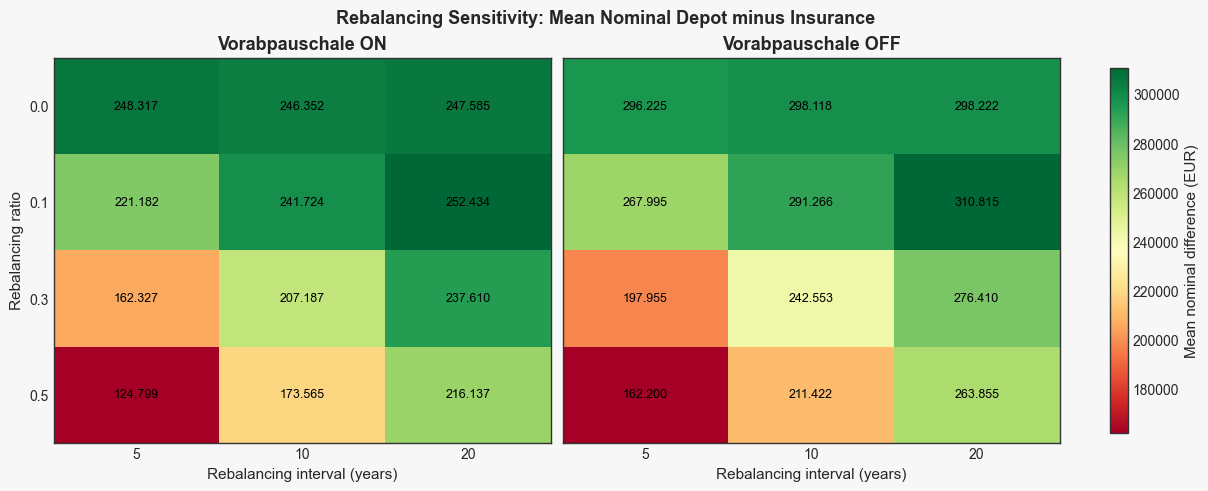

In [79]:
# Rebalancing sensitivity with and without Vorabpauschale
ratios = [0.0, 0.1, 0.3, 0.5]
intervals = [5, 10, 20]
runs_per_combo = 300

all_rows = []
for include_vorab in [True, False]:
    for ratio in ratios:
        for interval in intervals:
            cfg = dict(config)
            cfg["include_vorabpauschale"] = include_vorab
            cfg["rebalancing_ratio"] = ratio
            cfg["rebalancing_interval"] = interval

            seed = 50_000 + int(include_vorab) * 10_000 + int(ratio * 1000) + interval
            mc = run_monte_carlo(cfg, n_runs=runs_per_combo, seed_start=seed, sample_paths=0)

            all_rows.append(
                {
                    "vorabpauschale": "on" if include_vorab else "off",
                    "rebalancing_ratio": ratio,
                    "rebalancing_interval_years": interval,
                    "mean_diff_nominal_dep_minus_ins": mc["nominal_mean"],
                    "depot_win_rate_nominal": mc["dep_win_rate"],
                }
            )

sensitivity_df = pd.DataFrame(all_rows)
print("Sensitivity table (mean nominal depot-ins)")
print(sensitivity_df.round(2).to_string(index=False))

heat_on = sensitivity_df[sensitivity_df["vorabpauschale"] == "on"].pivot(
    index="rebalancing_ratio",
    columns="rebalancing_interval_years",
    values="mean_diff_nominal_dep_minus_ins",
)
heat_off = sensitivity_df[sensitivity_df["vorabpauschale"] == "off"].pivot(
    index="rebalancing_ratio",
    columns="rebalancing_interval_years",
    values="mean_diff_nominal_dep_minus_ins",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True, constrained_layout=True)
for ax, hm, title in [
    (axes[0], heat_on, "Vorabpauschale ON"),
    (axes[1], heat_off, "Vorabpauschale OFF"),
]:
    im = ax.imshow(hm.values, aspect="auto", cmap="RdYlGn", interpolation="nearest")
    ax.grid(False)
    ax.set_xticks(range(len(hm.columns)), [str(c) for c in hm.columns])
    ax.set_yticks(range(len(hm.index)), [str(i) for i in hm.index])
    ax.set_xlabel("Rebalancing interval (years)")
    ax.set_title(title)

    for i in range(len(hm.index)):
        for j in range(len(hm.columns)):
            val = hm.values[i, j]
            ax.text(
                j, i, format_number_de(val, 0), ha="center", va="center", color="black", fontsize=9
            )

axes[0].set_ylabel("Rebalancing ratio")
fig.suptitle(
    "Rebalancing Sensitivity: Mean Nominal Depot minus Insurance", fontsize=13, fontweight="bold"
)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.95)
cbar.set_label("Mean nominal difference (EUR)")
cbar.ax.yaxis.set_major_formatter(FuncFormatter(german_int_tick))
cbar.update_ticks()

plt.show()

In [80]:
# Sanity checks for model stability
sanity_rows = []

checks = [
    (
        "base",
        {
            "include_vorabpauschale": True,
            "volatility": config["volatility"],
            "assume_allowance_used_elsewhere": True,
        },
    ),
    (
        "vorab_off",
        {
            "include_vorabpauschale": False,
            "volatility": config["volatility"],
            "assume_allowance_used_elsewhere": True,
        },
    ),
    (
        "allowance_available",
        {
            "include_vorabpauschale": True,
            "volatility": config["volatility"],
            "assume_allowance_used_elsewhere": False,
        },
    ),
    (
        "volatility_0",
        {
            "include_vorabpauschale": True,
            "volatility": 0.0,
            "assume_allowance_used_elsewhere": True,
        },
    ),
]

for name, overrides in checks:
    cfg = dict(config)
    cfg.update(overrides)
    run = run_single_simulation(cfg, seed=123)

    sanity_rows.append(
        {
            "scenario": name,
            "dep_minus_ins_nominal": run["nominal_available_dep"] - run["nominal_available_ins"],
            "dep_minus_ins_real": run["real_available_dep"] - run["real_available_ins"],
        }
    )

sanity_df = pd.DataFrame(sanity_rows)
print("Sanity checks (single path, seed=123)")
print(sanity_df.round(2).to_string(index=False))

Sanity checks (single path, seed=123)
           scenario  dep_minus_ins_nominal  dep_minus_ins_real
               base              151921.18           118215.41
          vorab_off              175547.02           137281.33
allowance_available              151921.18           118215.41
       volatility_0              166382.02           126929.93
